In [1]:
from alerce.core import Alerce
from astropy.table import vstack, Table
import json
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
import george
import scipy.optimize as op
import emcee

In [2]:
import utils

In [3]:
curve_type = "Ia"

In [4]:
#open light curves
with open(f"../Data/{curve_type}.json", 'r') as f:
    light_curves = json.load(f)

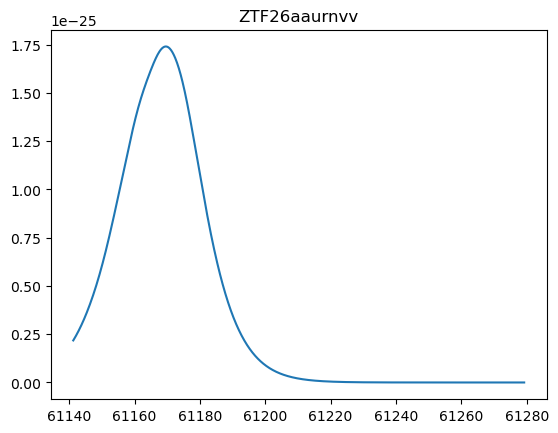

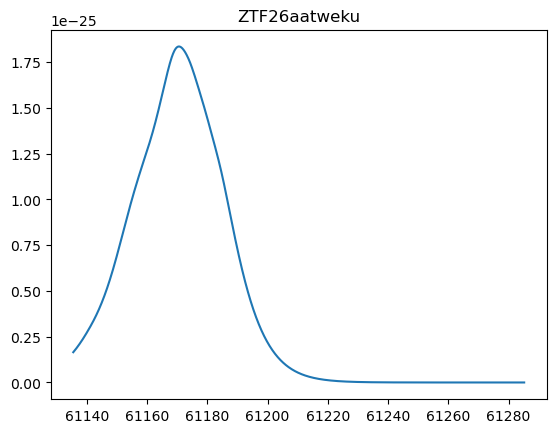

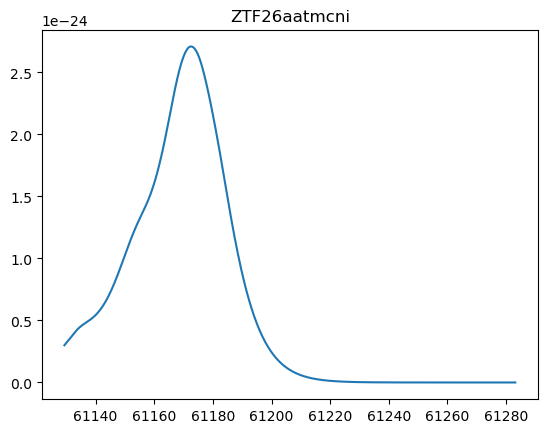

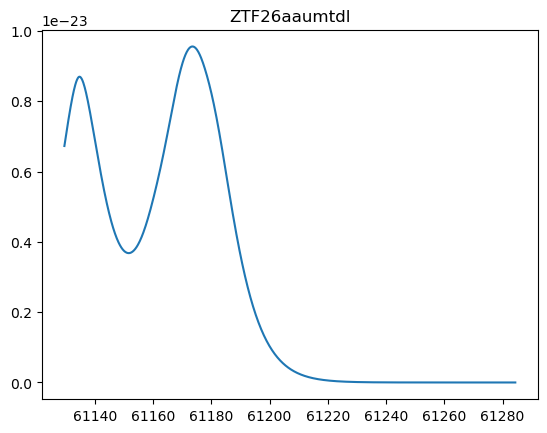

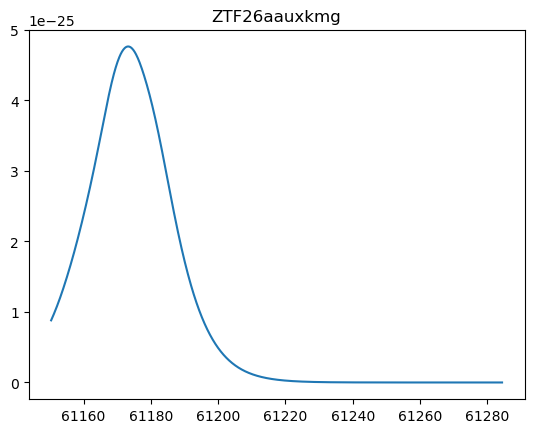

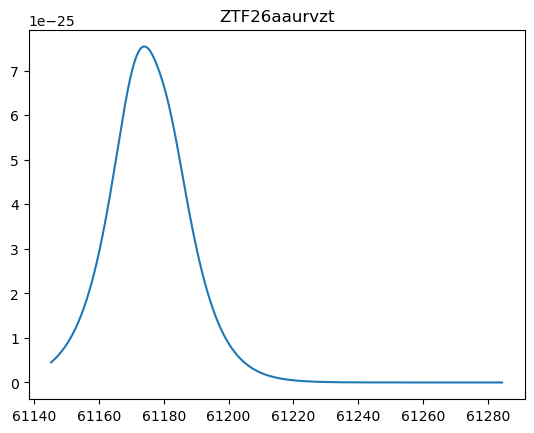

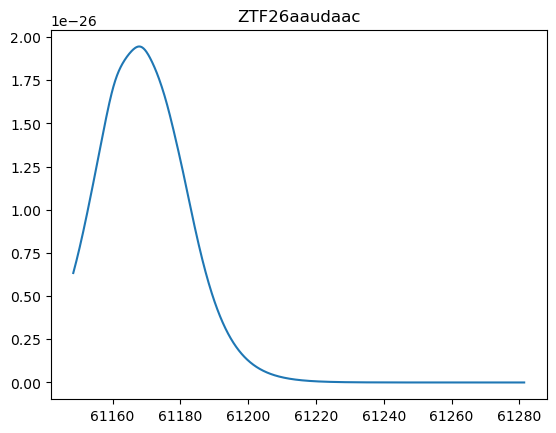

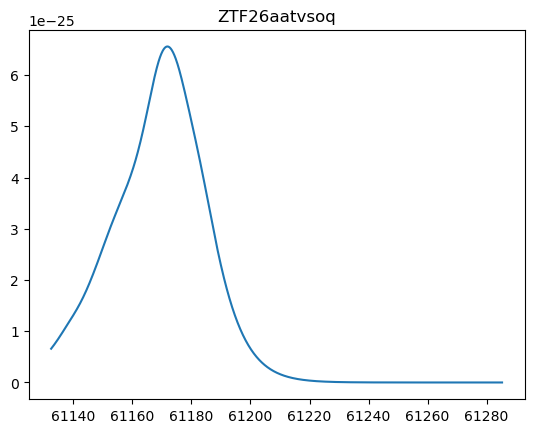

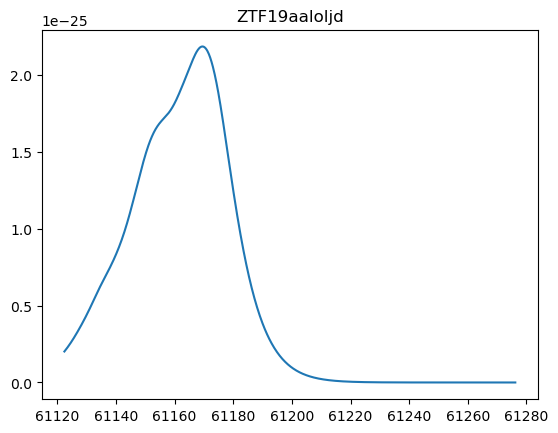

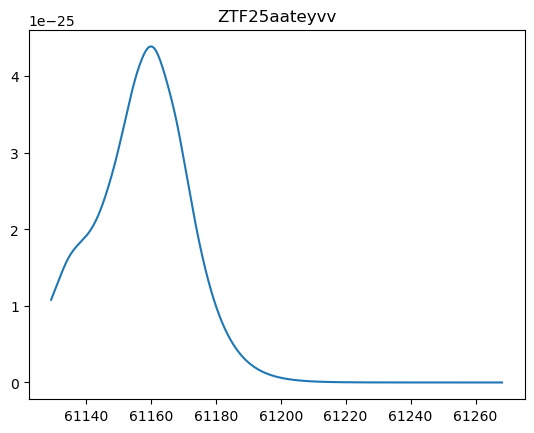

In [5]:
max_curves = 20
dic_curves = []
for light in light_curves[:max_curves]:

    if len(light) > 10:

        #fetch time, psuedo flux, and psuedo flux error
        time, mag_flipped, error = utils.decompose_curve(light)

        if len(mag_flipped) > 10:
            
            #fit line to curve
            pred, pred_var, x_fit = utils.fit_curve(time, mag_flipped, error, mode="george")

            #find peak
            peak = np.max(pred)

            #find rise time
            rise_time = utils.get_rise_time(pred, x_fit, peak, mode="slope")
            #print(rise_time)

            #find fall time
            fall_time = utils.get_fall_time(pred, x_fit, peak, mode="slope")

            if rise_time < 0 or fall_time < 0:
                rise_time = utils.get_rise_time(pred, x_fit, peak, mode="basic")
                fall_time = utils.get_fall_time(pred, x_fit, peak, mode="basic")

            #add curve to dictionary and append to list
            error = np.pow(pred_var, 0.5)    
            dic = {"object": light[0]["oid"], "type": f"SN{curve_type}", "mjd": x_fit, "mag": pred, 
                   "error": error, "peak": peak, "rise": rise_time, "fall": fall_time}
            dic_curves.append(dic)

            #plot fit
            plt.plot(x_fit, pred)
            plt.title(light[0]["oid"])
            plt.show()
            # if peak > 2.2 * 10**-18:
            #utils.plot_curve_fit(time, mag_flipped, x_fit, pred, light[0]["oid"], curve_type, round(peak, 2), round(rise_time, 2), round(fall_time, 2))

# table_curves = vstack(dic_curves)
# if curve_type == "Ia":
#     table_curves1 = table_curves[:len(table_curves)//2]
#     table_curves2 = table_curves[len(table_curves)//2:]
#     table_curves1.write(f"../Data/SN{curve_type}_fits1.ecsv", format='ascii.ecsv', overwrite=True)
#     table_curves2.write(f"../Data/SN{curve_type}_fits2.ecsv", format='ascii.ecsv', overwrite=True)
# else:
#     table_curves.write(f"../Data/SN{curve_type}_fits.ecsv", format='ascii.ecsv', overwrite=True)

In [6]:
Table(dic_curves)["object", "type", "peak", "rise", "fall"]

object,type,peak,rise,fall
str12,str4,float64,float64,float64
ZTF26aaurnvv,SNIa,1.7398434849707251e-25,28.17805069789756,109.67339340259787
ZTF26aatweku,SNIa,1.836139910980343e-25,34.92654170458263,114.67298027469951
ZTF26aatmcni,SNIa,2.7087977750625945e-24,43.11917471476772,110.56988373286731
ZTF26aaumtdl,SNIa,9.55594887222336e-24,43.85971138434252,110.81163830318837
ZTF26aauxkmg,SNIa,4.765492606396845e-25,22.794751235182048,111.02384719252586
ZTF26aaurvzt,SNIa,7.5394189424944225e-25,28.534175664171926,110.37854293506098
ZTF26aaudaac,SNIa,1.9461101506528416e-26,19.3043227813032,113.5626712582889
ZTF26aatvsoq,SNIa,6.559031907372773e-25,39.289534221701615,113.28227571315801
ZTF19aaloljd,SNIa,2.1870844383367685e-25,46.968012676188664,106.71748453967302
